In [253]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from pathlib import Path
import os
import zipfile
import json
from io import BytesIO

In [281]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

# В основном была нужна для ABC
pd.set_option('display.max_rows', None)

#### 1. Извлечение файлов из zip-архива, преобразования в датафреймы, разведочный EDA

In [255]:
# Формируем путь к нашему zip-архиву
path_for_data = Path(os.getcwd()) / 'data.zip'

In [256]:
# Проверяем содержимое архива
with zipfile.ZipFile(path_for_data, 'r') as zip_r:
    print('Содержимое архива:\n')
    for item in zip_r.namelist():
        if item.endswith('/'):
            continue
        print(item)
    print('-' * 40)

Содержимое архива:

data/orders.xlsx
data/products.xlsx
----------------------------------------


In [257]:
# Извлекаем данные из архива и помещаем в собственные именованные объекты
dataframes_list = []

with zipfile.ZipFile(path_for_data, 'r') as zip_ref:
    for item in zip_ref.namelist():
        if item.endswith('/'):
            continue

        if item.endswith('.xlsx'):
            filename = os.path.basename(item)
        
            with zip_ref.open(item) as file:
                df = pd.read_excel(BytesIO(file.read()))
                dataframes_list.append(df)
        else:
            print(f'Пропущен {item}')

if len(dataframes_list) >= 2:
    orders = dataframes_list[0] # Таблица заказов
    products = dataframes_list[1] # Таблица продуктов

In [258]:
orders.head() # Таблица заказов

,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price
0,1517514900,2022-01-13 16:48:19,17122,1,169,169,74
1,1517430051,2022-01-13 16:46:53,17122,1,169,169,74
2,1517578174,2022-01-13 18:12:30,17122,1,169,169,74
3,1517466327,2022-01-13 15:11:12,22199,1,219,219,130
4,1517429157,2022-01-13 19:15:59,22199,1,219,219,130


In [259]:
print(f'Количество данных в таблице: "orders": {orders.shape[0]}')

Количество данных в таблице: "orders": 3323


In [260]:
products.head() # Таблица продуктов

,product_id,level1,level2,name
0,1,Гигиена,Бритье,Кассеты для бритья Gillette Fusion ProGlide Po...
1,2,Мучные кондитерские изделия,Мучные кондитерские изделия,Печенье Бодрость
2,3,Мясная гастрономия,"Сосиски, сардельки",Сосиски Стародворье
3,4,Чай,Черный чай,Чай Азерчай
4,5,Безалкогольные напитки,Соковая продукция,Морс Valio


In [261]:
print(f'Количество данных в таблице: "products": {products.shape[0]}')

Количество данных в таблице: "products": 40152


In [262]:
# Посмотрим на небольшую статистистику с помощью "describe"

print(f'Размер таблицы "orders" {orders.shape}')
print(f'Размер таблицы "products" {products.shape}\n')

print(f'Предварительный EDA для таблицы "orders:\n"{orders.describe(include=np.number).round(2)}\n')
print(f'Предварительный EDA для таблицы "products:\n"{products.describe(include=np.object_).round(2)}')


Размер таблицы "orders" (3323, 7)
Размер таблицы "products" (40152, 4)

Предварительный EDA для таблицы "orders:
"              order_id  product_id  quantity  regular_price    price  \
count         3,323.00    3,323.00  3,323.00       3,323.00 3,323.00   
mean  1,517,528,695.50   22,961.38      1.24         139.83   130.65   
std         102,918.18   25,476.20      0.79         104.20    96.33   
min   1,517,207,363.00       23.00      1.00          11.00     4.00   
25%   1,517,453,576.00    6,008.00      1.00          77.00    72.00   
50%   1,517,524,215.00   12,114.00      1.00         117.00   109.00   
75%   1,517,605,355.00   30,321.50      1.00         179.00   165.00   
max   1,517,855,257.00  120,497.00     12.00       1,797.00 1,797.00   

       cost_price  
count    3,323.00  
mean        81.11  
std         61.51  
min          7.00  
25%         42.00  
50%         67.00  
75%        101.00  
max        808.00  

Предварительный EDA для таблицы "products:
"       level

In [263]:
# Смотрим дубли и пустые значения в таблицах:

print(f'Количество дубликатов в таблице "orders": {orders.duplicated().sum()}') # Отстуствуют
print(f'Количество дубликатов в таблице "products": {products.duplicated().sum()}\n') # Отсуствуют
print('-'*40)

print(f'\nПустые значения в таблице "orders":\n{orders.isnull().sum()}\n') # Отстуствуют
print('-'*40)
print(f'\nПустые значения в таблице "products":\n{products.isnull().sum()}') # Присутствуют в наименовании, но мы опираемся на id товара. Возможно промо

Количество дубликатов в таблице "orders": 0
Количество дубликатов в таблице "products": 0

----------------------------------------

Пустые значения в таблице "orders":
order_id         0
accepted_at      0
product_id       0
quantity         0
regular_price    0
price            0
cost_price       0
dtype: int64

----------------------------------------

Пустые значения в таблице "products":
product_id      0
level1          0
level2          0
name          212
dtype: int64


In [264]:
# Посмотрим какой за какие дни нам доступны данные:

orders['date_at'] = pd.to_datetime(orders['accepted_at']).dt.date
print(f'Минимальная дата: {orders.date_at.max()}')
print(f'Максимальная дата: {orders.date_at.min()}\n')
print('Вывод: данные представлены в таблице "orders" только за один день')

Минимальная дата: 2022-01-13
Максимальная дата: 2022-01-13

Вывод: данные представлены в таблице "orders" только за один день


#### 2. EDA

In [265]:
# Объеденим датасеты по product_id

orders_prod = pd.merge(products, orders, on='product_id', how='inner')
orders_prod.head()

,product_id,level1,level2,name,order_id,accepted_at,quantity,regular_price,price,cost_price,date_at
0,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517497108,2022-01-13 17:49:12,6,18,18,14,2022-01-13
1,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517494748,2022-01-13 20:12:01,2,18,18,14,2022-01-13
2,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517368853,2022-01-13 09:34:18,1,18,18,14,2022-01-13
3,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517676281,2022-01-13 08:21:53,2,18,18,14,2022-01-13
4,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517600286,2022-01-13 14:32:24,4,18,18,14,2022-01-13


**Самая ходовая товарная группа:**

In [282]:
# Сгруппировали по категория и отсортировали по убыванию количества
kat_group = (orders_prod
             .groupby('level1')['quantity'].sum()
             .reset_index(name='sum_quantity')
             .sort_values(by='sum_quantity'))
kat_group.tail()

,level1,sum_quantity
0,Бакалея,239
10,Кулинария,250
19,Свежие овощи,262
11,Молочная продукция,483
1,Безалкогольные напитки,534


**Распределение по категориям товаров:**

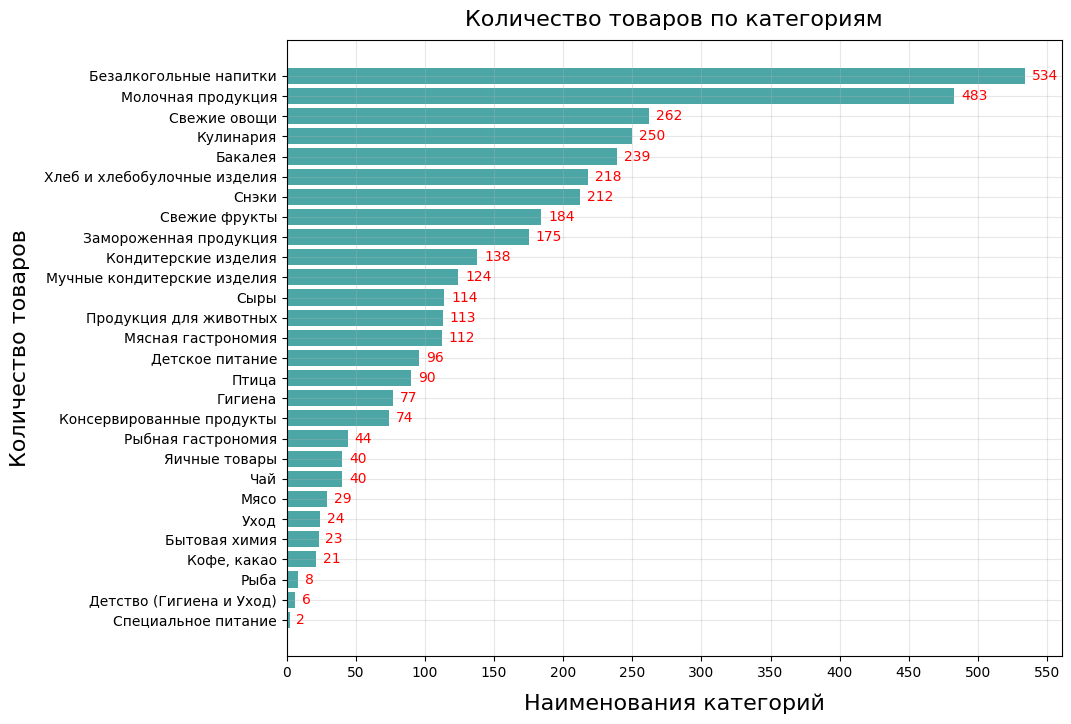

In [267]:
# Построим график распределения товаров по категориям

plt.figure(figsize=(10,8))

bars = plt.barh(y=kat_group['level1'], width=kat_group['sum_quantity'], color='teal', alpha=0.7)

plt.title('Количество товаров по категориям', pad=10, size=16)
plt.xlabel('Наименования категорий', size=16, labelpad=10)
plt.ylabel('Количество товаров', size=16, labelpad=10);
plt.grid(alpha=0.3)
plt.xticks(np.arange(0,600,50))
plt.bar_label(bars, padding=5, color='red')

plt.show()

In [268]:
# Построим таблицы распределения категорий товаров и подкатегорий по количеству

kat_podkat_qua = (orders_prod
                  .groupby(['level1', 'level2'])['quantity'].sum()
                  .reset_index(name='sum_quantity')
                  .sort_values(by='sum_quantity', ascending=False))
kat_podkat_qua.head()

,level1,level2,sum_quantity
13,Безалкогольные напитки,Напитки,252
54,Кулинария,Готовые блюда,248
95,Хлеб и хлебобулочные изделия,Хлеб и хлебобулочные изделия,218
86,Снэки,Снэки соленые,180
12,Безалкогольные напитки,Воды питьевые,162


**Средний чек:**

In [269]:
# Найдём средний чек в заданную дату: 2022-01-13
# Дата у нас одна в датафрейме
# Если даты не проверялись, то просто нужно отфильтровать датафрейм по нужной дате, можно через query например

avg_revenue_2 = (orders[['date_at', 'order_id', 'price', 'quantity']]
                 .assign(revenue=lambda x: x['price'] * x['quantity'])
                 .groupby('order_id')['revenue']
                 .sum()
                 .mean()
                 .round(2))
print(f'Средний чек в "2022-01-13" = {avg_revenue_2}')
print(f'Уникальные даты в датафрейме "orders": {orders.date_at.unique()}') # Она только одна

Средний чек в "2022-01-13" = 915.64
Уникальные даты в датафрейме "orders": [datetime.date(2022, 1, 13)]


**Доля промо в категории:**

In [270]:
# Фильтруем по категории Сыры и добавляем колонку, в которой будет True или False
# в зависимости от совпадения цен

dolya_promo = orders_prod[orders_prod['level1'] == 'Сыры'].copy()
dolya_promo['is_promo'] = dolya_promo['regular_price'] != dolya_promo['price']

true_dolya = (dolya_promo[dolya_promo['is_promo'] == True]['quantity'].sum() / dolya_promo['quantity'].sum()).round(3)
true_dolya

np.float64(0.307)

In [271]:
# Сформировали подготовительные данные для пайчарта

pie = {
    True:'Промо',
    False:'Не промо'
}

pie_group = dolya_promo.groupby('is_promo')['quantity'].sum().reset_index(name='quantity_cnt')
pie_group['is_promo'] = pie_group['is_promo'].map(pie)
pie_group

,is_promo,quantity_cnt
0,Не промо,79
1,Промо,35


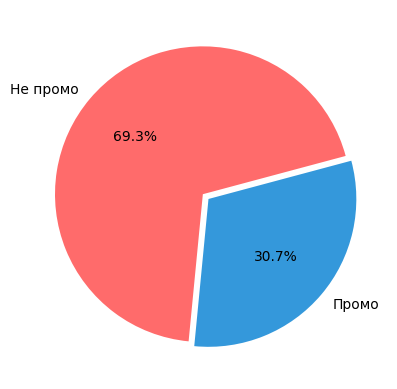

In [272]:
# Строим пайчарт

plt.pie(pie_group['quantity_cnt'], labels = pie_group['is_promo'], startangle=15, autopct='%.1f%%', explode=(0,0.05), colors=['#FF6B6B', '#3498db']);

**Маржа по категориям:**

In [273]:
orders_prod.head()

,product_id,level1,level2,name,order_id,accepted_at,quantity,regular_price,price,cost_price,date_at
0,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517497108,2022-01-13 17:49:12,6,18,18,14,2022-01-13
1,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517494748,2022-01-13 20:12:01,2,18,18,14,2022-01-13
2,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517368853,2022-01-13 09:34:18,1,18,18,14,2022-01-13
3,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517676281,2022-01-13 08:21:53,2,18,18,14,2022-01-13
4,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517600286,2022-01-13 14:32:24,4,18,18,14,2022-01-13


In [274]:
# Формируем таблицу с маржой по сумме и процентам

margin = orders_prod[['level1', 'quantity', 'price', 'cost_price']].copy()
# Добавляем вычисляемые колонки
margin['revenue'] = margin['price'] * margin['quantity']
margin['profit'] = (margin['price'] - margin['cost_price']) * margin['quantity']

# Группируем и считаем итоги
marg_df = margin.groupby('level1').agg(
    margin_rub=('profit', 'sum'),
    total_revenue=('revenue', 'sum')
).reset_index()

# Считаем маржу в процентах
marg_df['margin_perc'] = marg_df['margin_rub'] / marg_df['total_revenue'] * 100

# Оставляем нужные колонки
marg_df = marg_df[['level1', 'margin_rub', 'margin_perc']]
marg_df.head()

,level1,margin_rub,margin_perc
0,Бакалея,8177,37.57
1,Безалкогольные напитки,20373,44.19
2,Бытовая химия,1441,26.31
3,Гигиена,2971,29.55
4,Детское питание,1817,35.69


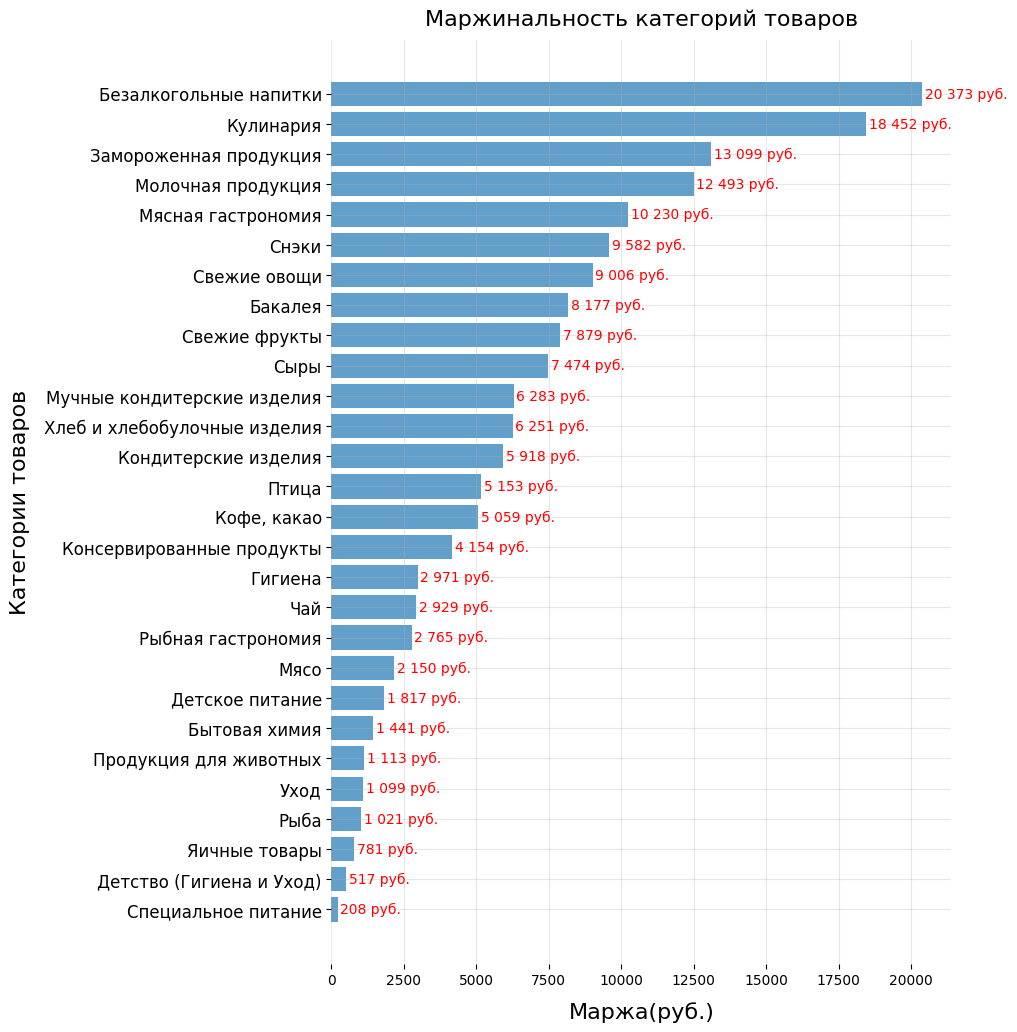

In [275]:
# Построим барплот горизонтальный для маржинальности в рублях

df_barplot_1 = marg_df.sort_values(by='margin_rub')

plt.figure(figsize=(8,12))

bar_marg_rub = plt.barh(y=df_barplot_1['level1'], width=df_barplot_1['margin_rub'], alpha=0.7)


for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.yticks(size=12)
plt.title('Маржинальность категорий товаров', pad=10, size=16)
plt.xlabel('Маржа(руб.)', size=16, labelpad=10)
plt.ylabel('Категории товаров', size=16, labelpad=10);
plt.grid(alpha=0.3)

labels = [f'{int(x):,} руб.'.replace(',', ' ') for x in df_barplot_1['margin_rub']]
plt.bar_label(bar_marg_rub, labels=labels, padding=2, color='red')

plt.show()

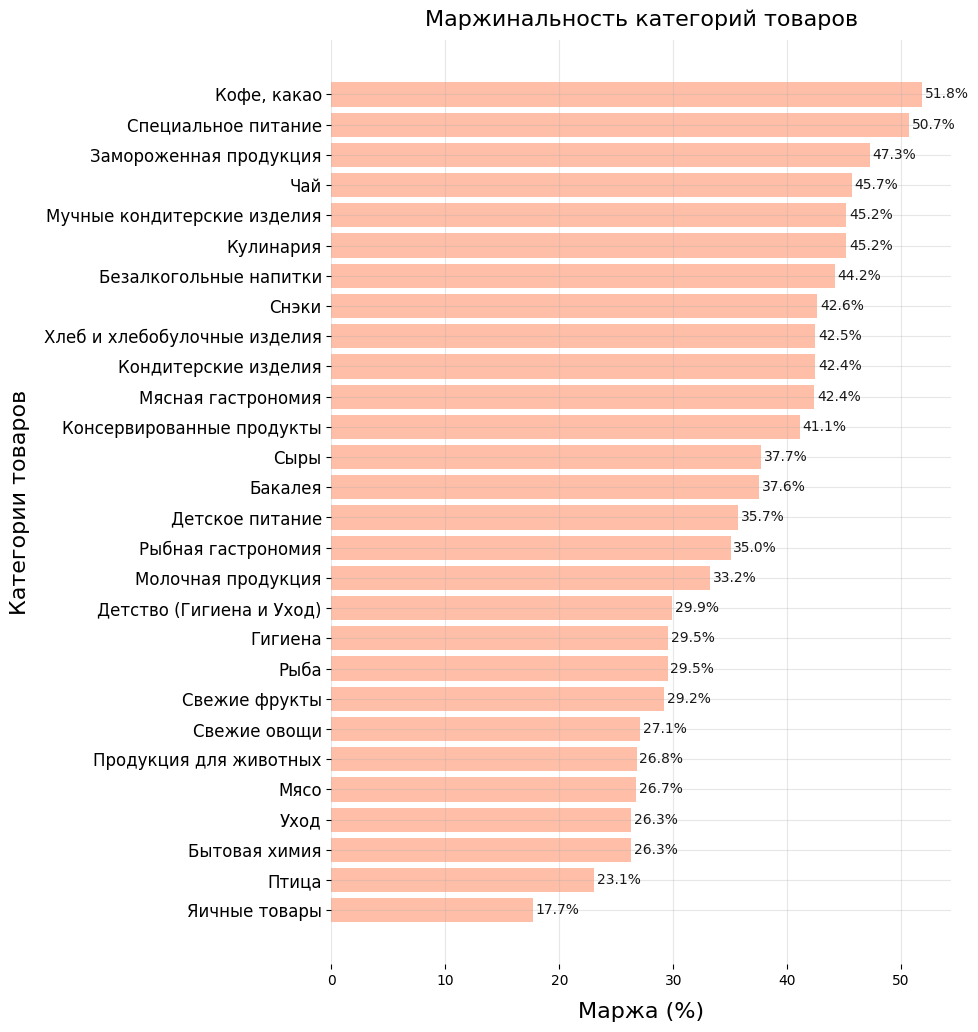

In [276]:
# Построим барплот горизонтальный для маржинальности в %


df_barplot_2 = marg_df.sort_values(by='margin_perc')

plt.figure(figsize=(8, 12))

bar_marg_perc = plt.barh(y=df_barplot_2['level1'], width=df_barplot_2['margin_perc'], alpha=0.5, color='coral')

for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.yticks(size=12)
plt.title('Маржинальность категорий товаров', pad=10, size=16)
plt.xlabel('Маржа (%)', size=16, labelpad=10)
plt.ylabel('Категории товаров', size=16, labelpad=10)
plt.grid(alpha=0.3)

labels = [f'{x:.1f}%' for x in df_barplot_2['margin_perc']]
plt.bar_label(bar_marg_perc, labels=labels, padding=2, alpha=0.9)

plt.show()

**ABC-анализ:**

In [277]:
orders_prod.head()

,product_id,level1,level2,name,order_id,accepted_at,quantity,regular_price,price,cost_price,date_at
0,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517497108,2022-01-13 17:49:12,6,18,18,14,2022-01-13
1,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517494748,2022-01-13 20:12:01,2,18,18,14,2022-01-13
2,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517368853,2022-01-13 09:34:18,1,18,18,14,2022-01-13
3,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517676281,2022-01-13 08:21:53,2,18,18,14,2022-01-13
4,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517600286,2022-01-13 14:32:24,4,18,18,14,2022-01-13


In [278]:
# Формируем датафрейм где посчитаем сумму по количесту и сумму по цене (цену переопределим
# по price * quantity)

data_ABC = ABC.groupby('level2').apply(lambda x: pd.Series({
    'price': (x['price'] * x['quantity']).sum(),
    'quantity': x['quantity'].sum()
}), include_groups=False).reset_index()
data_ABC.head()

,level2,price,quantity
0,"Бананы, косточковые и прочие плоды",10191,76
1,Бараночные и сухарные изделия,460,8
2,Бритье,731,3
3,Бумажная продукция,4569,42
4,Влажные салфетки,255,2


In [279]:
# Создаём функцию, которая будет присваивать наименования ABC
def set_abc(x):
    if x < 0.8:
        return 'A'
    elif x < 0.95:
        return 'B'
    else:
        return 'C'

# Считаем ABC по сумме продаж
data_ABC = data_ABC.sort_values('price', ascending=False)
data_ABC['dolya_price'] = data_ABC['price'] / sum(data_ABC['price'])
data_ABC['price_cumsum'] = data_ABC['dolya_price'].cumsum()
data_ABC['ABC_price'] = data_ABC['price_cumsum'].apply(set_abc)

# Считаем ABC по количеству
data_ABC = data_ABC.sort_values('quantity', ascending=False)
data_ABC['dolya_quantity'] = data_ABC['quantity'] / sum(data_ABC['quantity'])
data_ABC['quantity_cumsum'] = data_ABC['dolya_quantity'].cumsum()
data_ABC['ABC_quantity'] = data_ABC['quantity_cumsum'].apply(set_abc)

# Соединими колонки ABC по количеству продаж и по сумме продаж
data_ABC['ABC_join'] = data_ABC.filter(like='ABC').apply(''.join, axis=1)
data_ABC



,level2,price,quantity,dolya_price,price_cumsum,ABC_price,dolya_quantity,quantity_cumsum,ABC_quantity,ABC_join
51,Напитки,24123,252,0.05,0.14,A,0.07,0.07,A,AA
10,Готовые блюда,40356,248,0.09,0.09,A,0.07,0.13,A,AA
92,Хлеб и хлебобулочные изделия,14724,218,0.03,0.45,A,0.06,0.19,A,AA
72,Снэки соленые,17293,180,0.04,0.27,A,0.05,0.24,A,AA
6,Воды питьевые,9141,162,0.02,0.59,A,0.04,0.28,A,AA
33,"Корнеплоды, зелень и прочие овощи",14893,157,0.03,0.41,A,0.04,0.33,A,AA
40,Молоко и сливки,14902,147,0.03,0.38,A,0.04,0.37,A,AA
41,Молочно-десертные продукты,5999,116,0.01,0.71,A,0.03,0.40,A,AA
94,"Цитрусовые, семечковые и прочие плоды",16818,108,0.04,0.31,A,0.03,0.43,A,AA
26,Кисломолочные традиционные продукты,8760,106,0.02,0.61,A,0.03,0.45,A,AA


In [280]:
# Количество позиций в каждой категории 

abc_group = data_ABC['ABC_join'].value_counts().reset_index()
abc_group

,ABC_join,count
0,CC,32
1,AA,23
2,BB,15
3,BC,10
4,AB,9
5,BA,5
6,CB,4
7,CA,2
